Modern deep learning frameworks abstract away the mechanics of training. This notebook removes those abstractions and rebuilds the process from the ground up. Using only NumPy, it implements forward computation, manual backpropagation, and gradient-based optimization, exposing the full training loop that underlies neural network learning.

In [1]:
# importing libraries
import random
import numpy as np
import matplotlib.pyplot as plt

# set seeds for reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
np.random.default_rng(seed)

Generator(PCG64) at 0x7F5595728E40

# Linear function

A linear function is typically represented as:

$$f(x) = wx + b$$

Here is the numpy version of the equations.

In [2]:
def linear_fn(x, w, b):
  return w * x + b

def ground_truth(x):
  # example f(x) = wx + b
  return linear_fn(x, 2.0, 1.0)

# we know that w is 2.0 and b is 1.0
X = np.array([1, 3, 5, 7], dtype=float)
y = np.array(list(map(ground_truth, X)), dtype=float)
print(f"X: {X}")
print(f"y: {y}")

X: [1. 3. 5. 7.]
y: [ 3.  7. 11. 15.]


# Mean squared error

But how do we train a model so that the value of w becomes 2 and the value of b becomes 1?

1. Make a prediction using random values for w and b.
2. Calculate how wrong the prediction is.
3. Update the values w and b based on how wrong the prediction was.

We can calculate how wrong we are using this formula:
$$
L = \frac{1}{n} \sum (\hat{y} - y)^2
$$

This is actually **mean squared error**.

In [3]:
# start with random values for w and b, close to 0
w = random.uniform(-1.0, 1.0)
b = random.uniform(-1.0, 1.0)

# make a single prediction
y = ground_truth(1)
yHat = linear_fn(1, w, b)

# calculate the error using the formula
error = np.mean((yHat - y) ** 2)
print(f"Predicted {yHat:.2f}, with error {error:.2f}")

Predicted -0.67, with error 13.48


Running the previous cell a couple of times produces different predictions with different errors. This happens because the parameters are initialized randomly.

The next step is to update \( w \) and \( b \) so that they move closer to the ground-truth values.

**Basic rule: The derivative of a squared number is two times the number**

$$
\frac{d}{dx}(x^2) = 2x
$$

For a single squared error term,

$$
\frac{\partial}{\partial \hat{y}_i} (\hat{y}_i - y_i)^2 = 2(\hat{y}_i - y_i)
$$

For the full mean squared error the derivative with respect to the predictions is

$$
\frac{\partial L}{\partial \hat{y}} = \frac{2}{n}(\hat{y} - y)
$$

In [4]:
error = np.mean((yHat - y) ** 2)
print(f"Predicted {yHat:.2f}, with error {error:.2f}")

n_samples = 1 # we tested with one sample in previous cell
loss_dy = (2 / n_samples) * (yHat - y)
print(f"Derivative {loss_dy}")

Predicted -0.67, with error 13.48
Derivative -7.342249785277797


# Gradient descent
We average the losses across all the predictions to get this.

$$
\frac{\partial L}{\partial \hat{y}} = \frac{2}{n}(\hat{y} - y)
$$

Since $\hat{y} = wx + b$,

$$
\frac{\partial \hat{y}}{\partial w} = x
\qquad \text{and} \qquad
\frac{\partial \hat{y}}{\partial b} = 1
$$

Therefore we can calculate (dW) and (db) based on the chain rule,

$$
dW = \frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot x
$$

$$
db = \frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}}
$$

We then update the parameters using this formula:

$$
W = W - \eta \cdot dW
$$

$$
b = b - \eta \cdot db
$$

where \( $\eta$ \) is a small floating-point value called the learning rate.

We repeat this process multiple times so that \( w \) and \( b \) gradually get closer to the ground-truth values.

This is **gradient descent**.

In this notebook, I use **batch gradient descent**, because the gradients are computed using all training samples at each step.

In [5]:
# reinit X and y
X = np.array([1, 3, 5, 7], dtype=float)
y = np.array(list(map(ground_truth, X)), dtype=float)

# reinit with random values for w and b, close to 0
w = random.uniform(-1.0, 1.0)
b = random.uniform(-1.0, 1.0)

eta = 0.01
n = len(X)

for epoch in range(1000):

    # make a prediction
    yHat = w * X + b

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # calculate gradients
    dw = (2/n) * np.sum(X * (yHat - y))
    db = (2/n) * np.sum(yHat - y)

    # update the initial values(weight * bias)
    w = w - eta * dw
    b = b - eta * db


print("After Train Results")
print(f"w: {w} b: {b}")

After Train Results
w: 2.0020111558064233 b: 0.9895569077487354


This is great for scalars. What if we have multiple features?

We modify the formula to
$$f(x) = Wx + b$$

which translates to

$$
f(x) = w_1 x_1 + w_2 x_2 + b
$$


For this to work, we need to match the number of features and the weights and we only need one bias per output.

In [6]:
# two features per sample and a single target
# the target is (feature1 + feature2 + 1)
X = np.array([[1, 1], [3, 3], [5, 5], [7, 7]], dtype=float)
y = np.array([[3], [7], [11], [15]], dtype=float)

n_features = X.shape[1]
n_output_features = y.shape[1]

w = np.random.uniform(-1.0, 1.0, size=(n_features, n_output_features))
b = np.random.uniform(-1.0, 1.0, size=(1, n_output_features))

lr = 0.01 # eta
n_samples = len(X) # Number of samples

for epoch in range(2000): # Increased epochs for better convergence

    # make a prediction
    yHat = X @ w + b # (n_samples, n_output_features)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # calculate the derivate of the loss fn
    dloss_dy = (2 / n_samples) * (yHat - y)

    # calculate gradients
    dw = X.T @ dloss_dy
    db = np.sum(dloss_dy, axis=0, keepdims=True)

    # update the weights and biases
    w = w - lr * dw
    b = b - lr * db

print("After Train Results")
print(f"w: {w} b: {b}")

After Train Results
w: [[0.42382906]
 [1.57617743]] b: [[0.99996612]]


# Creating a Linear Layer Class

Let's wrap this into a LinearLayer class and test it using generated data.

In [7]:
# Save this class to the src folder for reuse across notebooks
# %%writefile src/layers.py
class LinearLayer:
    def __init__(self, in_features:int, out_features:int):
        self.w = 0.01 * np.random.randn(in_features, out_features) # make weights really small
        self.b = np.zeros((1, out_features)) # we need one bias per output feature

    def forward(self, x):
        self.x = x
        return x @ self.w + self.b

    def backward(self, dout):
        self.dw = self.x.T @ dout
        self.db = np.sum(dout, axis=0, keepdims=True)
        dx = dout @ self.w.T
        return dx

    def step(self, lr):
        self.w = self.w - (self.dw * lr)
        self.b = self.b - (self.db * lr)

In [8]:
# two features per sample and the target is (feature1 + feature2 + 1)
X = np.array([[1, 1], [3, 3], [5, 5], [7, 7]], dtype=float)
y = np.array([[3], [7], [11], [15]], dtype=float)

ll = LinearLayer(in_features=2, out_features=1)

lr = 0.01 # eta
n_samples = len(X)

for epoch in range(2000):

    # make a prediction
    yHat = ll.forward(X)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # # calculate the derivative of the loss function
    dloss_dy = (2 / n_samples) * (yHat - y)

    # update gradients
    ll.backward(dloss_dy)

    ll.step(lr)

print("After Train Results")
print(f"w0: {ll.w[0]} w1: {ll.w[1]} b: {ll.b[0]}")

# since our data is n*n+1 we expect the sum of weights to be 2
print(f"The sum of w {(ll.w[0]+ll.w[1])[0]:.2f}, expected 2.0")

After Train Results
w0: [0.99285253] w1: [1.00716035] b: [0.99993274]
The sum of w 2.00, expected 2.0


# ReLU activation function

To be able to create a useful neural network we need to introduce nonlinearity. We are going to use a **ReLU** activation function.

$$
A = \max(0, Z)
$$

and **ReLU** derivative

$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$


In [9]:
# Save this class to the src folder for reuse across notebooks
# %%writefile src/activations.py

class ReLU:

    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, dout):
        dx = dout * (self.x > 0.0)
        return dx

In [10]:
ll1 = LinearLayer(in_features=2, out_features=3)
relu = ReLU()
ll2 = LinearLayer(in_features=3, out_features=1)

X = np.array([[1, 1], [3, 3], [5, 5], [7, 7]], dtype=float)
y = np.array([[3], [7], [11], [15]], dtype=float)

lr = 0.001
n = len(X)

losses = []

for epoch in range(300):

    # forward pass
    x = ll1.forward(X)
    x = relu.forward(x)

    yHat = ll2.forward(x)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)
    losses.append(mse)

    # derivative of loss fn
    dloss_dy = (2/n) * (yHat - y)

    # gradient descent
    grad = ll2.backward(dloss_dy)
    grad = relu.backward(grad)
    grad = ll1.backward(grad)

    ll1.step(lr)
    ll2.step(lr)

num = 8.0
test_x = np.array([[num, num]])
yHatTest = ll2.forward(relu.forward(ll1.forward(test_x)))
print(f"Test outcome: {yHatTest[0][0]}, expected {num+num+1}")

Test outcome: 17.021370432044943, expected 17.0


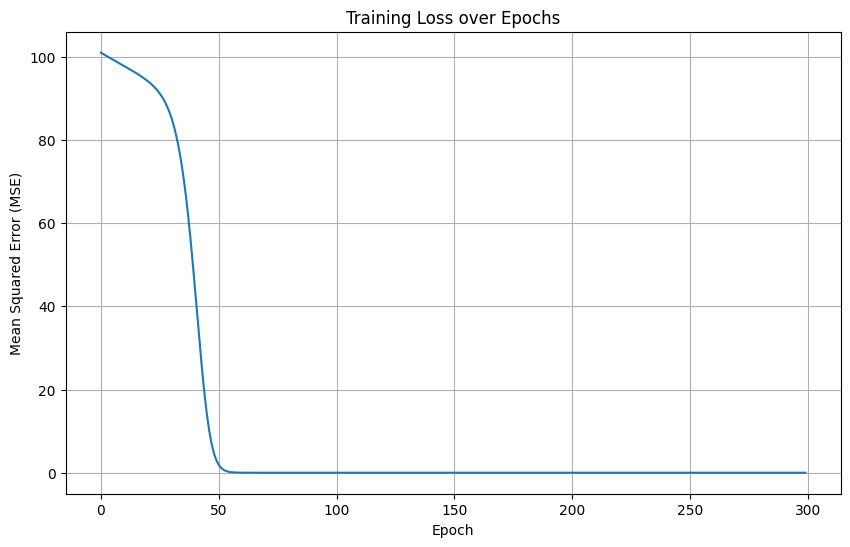

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

# Run a few experiments with learning rate




Starting training with learning rate: 0.05
Finished training with learning rate: 0.05, Final MSE: 20.0000

Starting training with learning rate: 0.01
Finished training with learning rate: 0.01, Final MSE: 20.0005

Starting training with learning rate: 0.005
Finished training with learning rate: 0.005, Final MSE: 0.0000

Starting training with learning rate: 0.001
Finished training with learning rate: 0.001, Final MSE: 44.4652


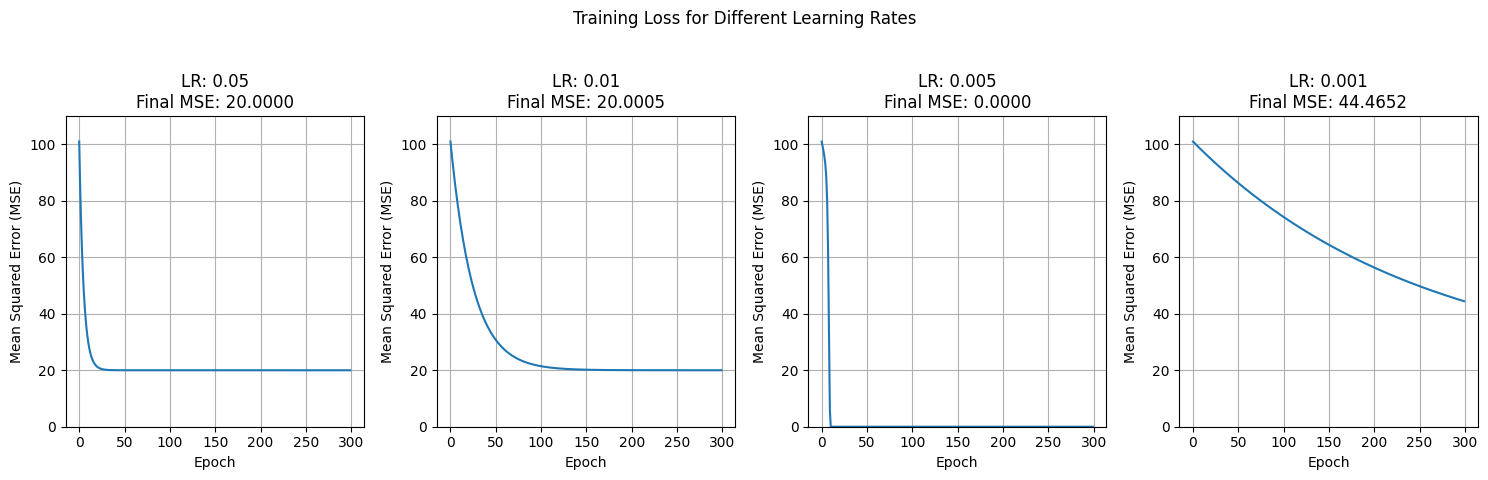

In [12]:

learning_rates = [0.05, 0.01, 0.005, 0.001]
all_losses = {}

X = np.array([[1, 1], [3, 3], [5, 5], [7, 7]], dtype=float)
y = np.array([[3], [7], [11], [15]], dtype=float)
n = len(X)

num_epochs = 300

for lr in learning_rates:
    print(f"\nStarting training with learning rate: {lr}")

    # re-initialize layers for each learning rate experiment to ensure fair comparison
    ll1 = LinearLayer(in_features=2, out_features=3)
    relu = ReLU()
    ll2 = LinearLayer(in_features=3, out_features=1)

    current_losses = []

    for epoch in range(num_epochs):
        # forward pass
        x_out = ll1.forward(X)
        x_out = relu.forward(x_out)
        yHat = ll2.forward(x_out)

        # calculate the loss
        mse = np.mean((y - yHat) ** 2)
        current_losses.append(mse)

        # backward pass
        dloss_dy = (2 / n) * (yHat - y)
        grad = ll2.backward(dloss_dy)
        grad = relu.backward(grad)
        ll1.backward(grad)

        # update weights
        ll1.step(lr)
        ll2.step(lr)

    all_losses[str(lr)] = current_losses
    print(f"Finished training with learning rate: {lr}, Final MSE: {current_losses[-1]:.4f}")

# plot the loss functions in a grid plot
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 5))
fig.suptitle('Training Loss for Different Learning Rates')

for i, lr_str in enumerate(learning_rates):
    ax = axes[i]
    losses_for_lr = all_losses[str(lr_str)]
    ax.plot(losses_for_lr)
    ax.set_title(f'LR: {lr_str}\nFinal MSE: {losses_for_lr[-1]:.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error (MSE)')
    ax.set_ylim(0, 110)
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

It is interesting to observe how the learning rate affects the training process. In these experiments, a learning rate of 0.05 and 0.01 stops at an MSE of about 20, 0.005 reaches an error of 0 in like 20 epochs, while 0.001 performs worse and remains at a much higher error. Maybe if we train for more epochs the error will go down.

Because the weights are initialized randomly, the linear outputs in the first layer can become negative for all inputs. In that case, ReLU maps them to zero, which can prevent the network from learning effectively.

In future notebooks I will explore different kinds of weight initializations to improve learning. (Xavier  and Kaiming He weight initializations)